<a href="https://colab.research.google.com/github/krshrey10/Fake_News_Detection/blob/main/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1: Install Required Libraries**

---



In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
import joblib
nltk.download(['punkt', 'stopwords', 'wordnet'])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

# **Step 2: Load and Explore the Dataset**

---



**2.1 Load Dataset**

In [4]:
# Load dataset from Kaggle (you'll need to upload the CSV first)
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


**2.2 Exploratory Data Analysis**

label
1    23481
0    21417
Name: count, dtype: int64


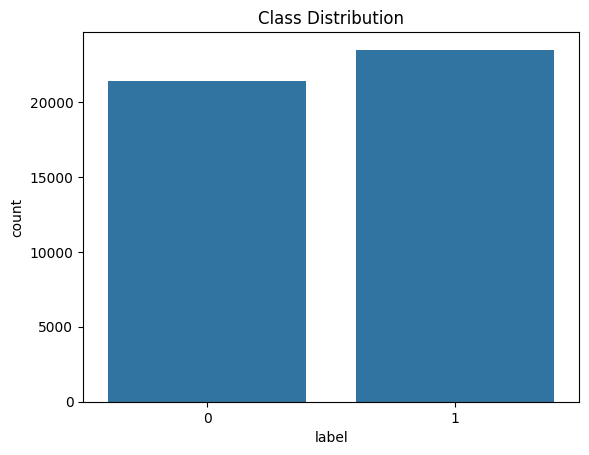

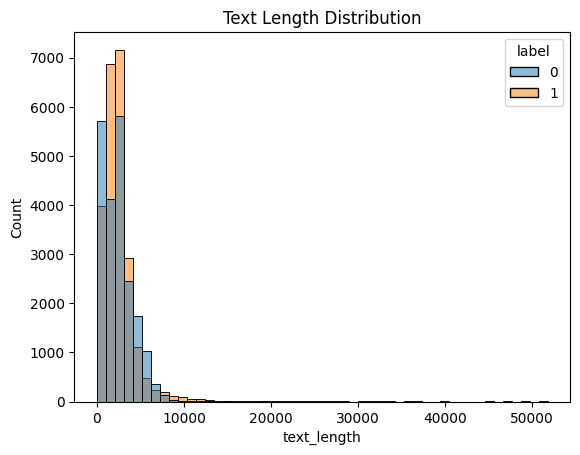

In [12]:
# Check class distribution
print(df['label'].value_counts())
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.show()

# Check text length
df['text_length'] = df['text'].apply(len)
sns.histplot(data=df, x='text_length', hue='label', bins=50)
plt.title('Text Length Distribution')
plt.show()

In [11]:
import zipfile
import os
import pandas as pd

# Assuming the uploaded file is a zip file named 'archive (2).zip'
zip_file_name = 'archive (2).zip'
extracted_folder_name = 'extracted_data'

# Create a directory to extract the contents
os.makedirs(extracted_folder_name, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extracted_folder_name)

# Load Fake.csv and add a 'label' column with value 1 (or 'fake')
fake_csv_path = os.path.join(extracted_folder_name, 'Fake.csv')
fake_df = pd.read_csv(fake_csv_path, encoding='latin-1')
fake_df['label'] = 1 # or 'fake'

# Load True.csv and add a 'label' column with value 0 (or 'true')
true_csv_path = os.path.join(extracted_folder_name, 'True.csv')
true_df = pd.read_csv(true_csv_path, encoding='latin-1')
true_df['label'] = 0 # or 'true'

# Combine the two dataframes
df = pd.concat([fake_df, true_df], ignore_index=True)

# Display the first few rows and info to verify
display(df.head())
display(df.info())

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obamaâs Na...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


None

In [7]:
import os

extracted_folder_name = 'extracted_data'
print(os.listdir(extracted_folder_name))

['Fake.csv', 'True.csv']


In [10]:
print(df.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')


# **Step 3: Data Preprocessing**

---



**3.1 Clean Text Data**

In [13]:
def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

**3.2 Tokenization and Lemmatization**

In [23]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = [token for token in tokens if token not in stop_words]
    return ' '.join(tokens)

df['processed_text'] = df['cleaned_text'].apply(preprocess_text)

In [15]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# **Step 4: Feature Extraction & Model Training**

---



**4.1 Train-Test Split**

In [24]:
X = df['processed_text']
y = df['label'].map({0: 0, 1: 1})  # Ensure labels are binary (0 or 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

**4.2 Create Pipeline with TF-IDF and Logistic Regression**

In [25]:
# Create pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression())
])

# Train model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', LogisticRegression())])

**4.3 Model Evaluation**

Accuracy: 0.9879732739420936

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4247
           1       0.99      0.99      0.99      4733

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



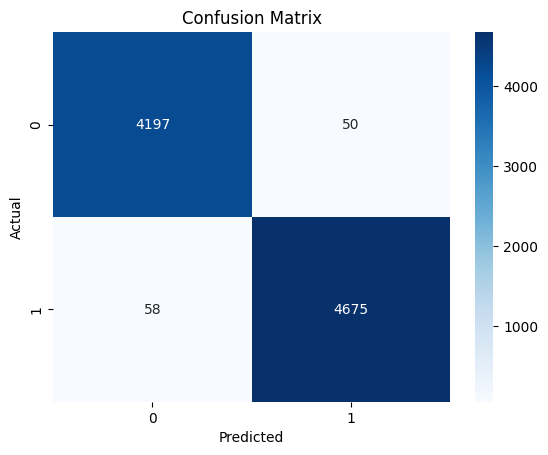

In [26]:
# Predictions
y_pred = pipeline.predict(X_test)

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **Step 5: Save Model & Create Prediction Function**

---



**5.1 Save the Model**

In [27]:
# Save the entire pipeline
joblib.dump(pipeline, 'fake_news_detector.pkl')

# Save to Google Drive
from google.colab import drive
drive.mount('/content/drive')
joblib.dump(pipeline, '/content/drive/MyDrive/fake_news_detector.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['/content/drive/MyDrive/fake_news_detector.pkl']

**5.2 Create Prediction Function**

In [28]:
def predict_news(text):
    # Load model
    model = joblib.load('fake_news_detector.pkl')
    # Clean and preprocess input text
    cleaned = clean_text(text)
    processed = preprocess_text(cleaned)
    # Make prediction
    prediction = model.predict([processed])[0]
    return "Real News" if prediction == 1 else "Fake News"

# Test the function
sample_text = "Scientists have discovered a new planet that could support life."
print(predict_news(sample_text))

Real News
